<b><h2>1. Data Aquisition

In [2]:
# ==========================================
# STEP 1: LOAD & EXPLORE THE DATASET
# ==========================================

!pip install datasets -q

import pandas as pd
from datasets import load_dataset

print("🛰️ Connecting to cloud database...")
# Load the arXiv classification dataset (already single-label, 11 research categories)
full_dataset = load_dataset("ccdv/arxiv-classification", split="train")

# Convert to a clean Pandas DataFrame
df = full_dataset.to_pandas()

print("✅ Dataset loaded.")
print("Shape:", df.shape)
print("\nColumns available:", df.columns.tolist())
df.head()

🛰️ Connecting to cloud database...


README.md:   0%|          | 0.00/3.30k [00:00<?, ?B/s]

data/train-00000-of-00004.parquet:   0%|          | 0.00/218M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/28388 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

✅ Dataset loaded.
Shape: (28388, 2)

Columns available: ['text', 'label']


,text,label
0,Constrained Submodular Maximization via a\nNon...,8
1,Self Organizing Maps Whose Topologies Can Be L...,9
2,Robust Satisfaction of Temporal Logic Specific...,3
3,BATCHED QR AND SVD ALGORITHMS ON GPUS WITH APP...,8
4,Analytical and simplified models for dynamic a...,5


In [3]:
# ==========================================
# STEP 2: CHECK CATEGORY DISTRIBUTION
# ==========================================

print("📊 Number of unique categories:", df['label'].nunique())
print("\nRow count per category:")
print(df['label'].value_counts())

print("\nMin category size:", df['label'].value_counts().min())
print("Max category size:", df['label'].value_counts().max())

📊 Number of unique categories: 11

Row count per category:
label
8     3527
7     2768
3     2631
4     2599
10    2581
2     2569
9     2560
0     2456
6     2443
1     2137
5     2117
Name: count, dtype: int64

Min category size: 2117
Max category size: 3527


In [4]:
# ==========================================
# STEP 3: CHECK TEXT LENGTH (important — arXiv full-text can be very long as it contains full paper text)
# ==========================================

df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
print(df['text_length'].describe())

count     28388.000000
mean      10559.958187
std       10184.477775
min         441.000000
25%        5710.500000
50%        8424.500000
75%       12795.000000
max      553206.000000
Name: text_length, dtype: float64


In [5]:
# ==========================================
# STEP 4: GET ACTUAL CATEGORY NAMES (not just numbers)
# ==========================================

# The dataset stores label as ClassLabel feature with real names attached
label_feature = full_dataset.features['label']
label_names = label_feature.names

print("Label ID → Category Name mapping:")
for i, name in enumerate(label_names):
    print(i, "→", name)

Label ID → Category Name mapping:
0 → math.AC
1 → cs.CV
2 → cs.AI
3 → cs.SY
4 → math.GR
5 → cs.CE
6 → cs.PL
7 → cs.IT
8 → cs.DS
9 → cs.NE
10 → math.ST


In [6]:
# ==========================================
# STEP 5 (REVISED): EXTRACT REAL ABSTRACTS USING REGEX
# ==========================================

import re

def extract_abstract(text):
    text = str(text)

    # Find text between "Abstract" and the next major section heading
    # Common section headings that follow an abstract: Introduction, 1 Introduction, I. Introduction, Keywords
    pattern = re.compile(
        r'abstract\s*[:\-]?\s*(.*?)(?=\n?\s*(1\.?\s*introduction|introduction|keywords|index terms))',
        re.IGNORECASE | re.DOTALL
    )

    match = pattern.search(text)
    if match:
        abstract = match.group(1).strip()
        # Clean up excessive whitespace/newlines
        abstract = re.sub(r'\s+', ' ', abstract)
        return abstract
    else:
        return None  # flag papers where extraction failed

df['extracted_abstract'] = df['text'].apply(extract_abstract)

# Check how many extractions succeeded
success_count = df['extracted_abstract'].notna().sum()
print(f"✅ Successfully extracted abstracts: {success_count} / {len(df)} ({success_count/len(df)*100:.1f}%)")

# Look at a sample
print("\nSample extracted abstract:\n")
print(df['extracted_abstract'].iloc[0])

✅ Successfully extracted abstracts: 24230 / 28388 (85.4%)

Sample extracted abstract:

The study of combinatorial optimization problems with a submodular objective has attracted much attention in recent years. Such problems are important in both theory and practice because their objective functions are very general. Obtaining further improvements for many submodular maximization problems boils down to finding better algorithms for optimizing a relaxation of them known as the multilinear extension. In this work we present an algorithm for optimizing the multilinear relaxation whose guarantee improves over the guarantee of the best previous algorithm (which was given by Ene and Nguyen (2016)). Moreover, our algorithm is based on a new technique which is, arguably, simpler and more natural for the problem at hand. In a nutshell, previous algorithms for this problem rely on symmetry properties which are natural only in the absence of a constraint. Our technique avoids the need to resort to

In [7]:
# ==========================================
# STEP 5b: CLEAN UP LEFTOVER FOOTNOTE/AFFILIATION NOISE
# ==========================================

def clean_abstract(text):
    if text is None:
        return None

    # Cut off at the first occurrence of common footnote/affiliation markers
    # These usually signal "abstract content has ended, footer junk begins"
    cutoff_pattern = re.compile(
        r'(∗|\*|†|‡|department of|email:|@\w+\.\w+|university,|school of)',
        re.IGNORECASE
    )

    match = cutoff_pattern.search(text)
    if match:
        text = text[:match.start()].strip()

    return text

df['extracted_abstract'] = df['extracted_abstract'].apply(clean_abstract)

# Re-check after cleanup
print(df['extracted_abstract'].iloc[0])
print("\nLength check after cleanup:")
print(df['extracted_abstract'].apply(lambda x: len(str(x).split())).describe())

The study of combinatorial optimization problems with a submodular objective has attracted much attention in recent years. Such problems are important in both theory and practice because their objective functions are very general. Obtaining further improvements for many submodular maximization problems boils down to finding better algorithms for optimizing a relaxation of them known as the multilinear extension. In this work we present an algorithm for optimizing the multilinear relaxation whose guarantee improves over the guarantee of the best previous algorithm (which was given by Ene and Nguyen (2016)). Moreover, our algorithm is based on a new technique which is, arguably, simpler and more natural for the problem at hand. In a nutshell, previous algorithms for this problem rely on symmetry properties which are natural only in the absence of a constraint. Our technique avoids the need to resort to such properties, and thus, seems to be a better fit for constrained problems.

Length 

In [8]:
# ==========================================
# STEP 6: MAP LABEL IDS TO NAMES IN THE DATAFRAME
# ==========================================

id_to_name = {i: name for i, name in enumerate(label_names)}
df['category'] = df['label'].map(id_to_name)

print(df[['label', 'category']].drop_duplicates().sort_values('label'))

    label category
9       0  math.AC
6       1    cs.CV
24      2    cs.AI
2       3    cs.SY
32      4  math.GR
4       5    cs.CE
7       6    cs.PL
21      7    cs.IT
0       8    cs.DS
1       9    cs.NE
14     10  math.ST


In [9]:
# ==========================================
# STEP 5c: FILTER OUT FAILED / TOO-SHORT EXTRACTIONS
# ==========================================

# Drop rows where extraction failed entirely
df_clean = df.dropna(subset=['extracted_abstract']).copy()

# Also drop abstracts that became too short after cleanup (likely over-aggressive cutoff)
MIN_WORDS = 30
df_clean['abstract_word_count'] = df_clean['extracted_abstract'].apply(lambda x: len(str(x).split()))
df_clean = df_clean[df_clean['abstract_word_count'] >= MIN_WORDS]

print(f"Final clean dataset size: {len(df_clean)} / {len(df)} ({len(df_clean)/len(df)*100:.1f}%)")
print("\nCategory distribution after cleaning:")
print(df_clean['category'].value_counts())

Final clean dataset size: 23597 / 28388 (83.1%)

Category distribution after cleaning:
category
cs.DS      3236
math.GR    2216
cs.AI      2200
math.ST    2188
cs.IT      2098
cs.NE      2070
cs.SY      2051
math.AC    2039
cs.PL      1903
cs.CV      1847
cs.CE      1749
Name: count, dtype: int64


In [10]:
# ==========================================
# STEP 7 : BALANCED SAMPLING (~5,000 rows total)
# ==========================================

TARGET_TOTAL = 5000
n_categories = df_clean['category'].nunique()
samples_per_category = TARGET_TOTAL // n_categories

print(f"Target ~{samples_per_category} rows per category across {n_categories} categories")

balanced_df = (
    df_clean
    .groupby('category', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), samples_per_category), random_state=42))
)

print("\nFinal balanced dataset shape:", balanced_df.shape)
print("\nCategory distribution:")
print(balanced_df['category'].value_counts())

Target ~454 rows per category across 11 categories

Final balanced dataset shape: (4994, 6)

Category distribution:
category
cs.AI      454
cs.CE      454
cs.CV      454
cs.DS      454
cs.IT      454
cs.NE      454
cs.PL      454
cs.SY      454
math.AC    454
math.GR    454
math.ST    454
Name: count, dtype: int64


/tmp/ipykernel_2385/499751147.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), samples_per_category), random_state=42))


In [11]:
# ==========================================
# STEP 8: FINALIZE & SAVE
# ==========================================

final_df = balanced_df[['extracted_abstract', 'category', 'label']].rename(
    columns={'extracted_abstract': 'abstract'}
).reset_index(drop=True)

filename = "research_domain_classification_5k.csv"
final_df.to_csv(filename, index=False)

print(f"💾 Saved {len(final_df)} rows to {filename}")
final_df.head()

💾 Saved 4994 rows to research_domain_classification_5k.csv


,abstract,category,label
0,Autonomous systems can substantially enhance a...,cs.AI,2
1,". In this paper, we develop a novel paradigm, ...",cs.AI,2
2,We introduce a framework to leverage knowledge...,cs.AI,2
3,Performance of data-driven network for tumor c...,cs.AI,2
4,Theory of Mind is the ability to attribute men...,cs.AI,2


In [12]:
final_df.shape

(4994, 3)

<b><h2>2. EDA

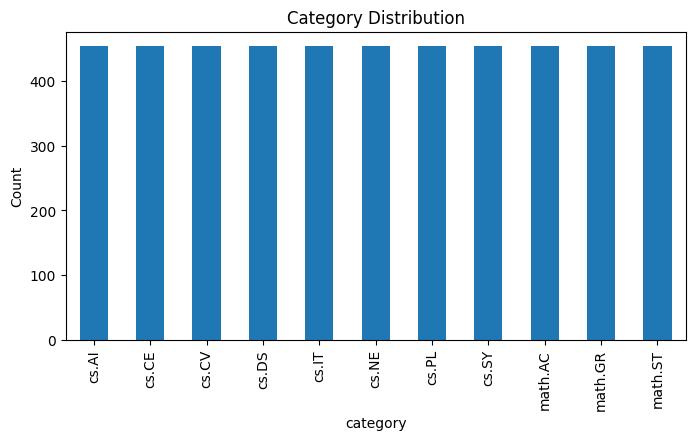

count     4994.000000
mean       252.877253
std        697.878008
min         30.000000
25%        106.000000
50%        150.000000
75%        208.000000
max      16246.000000
Name: word_count, dtype: float64


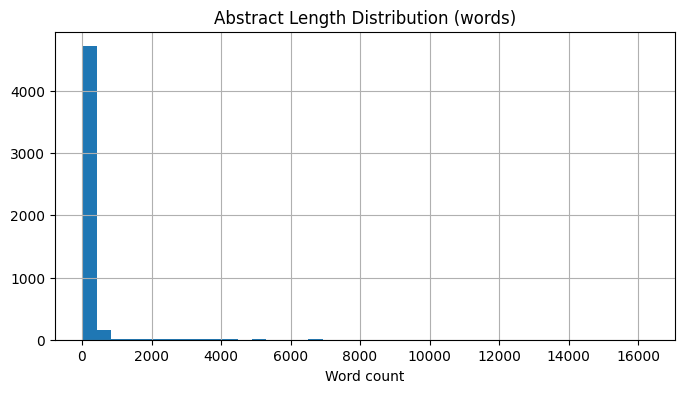


Duplicate abstracts: 41

--- cs.AI ---
Autonomous systems can substantially enhance a human’s efficiency and effectiveness in complex environments. Machines, however, are often unable to observe the preferences of the humans that they serve. Despite the fact that the human’s and machine’s objectives are aligned, asymmetric information, a ...

--- cs.CE ---
. Fracture material is seriously problem in daily life, and it has connection with mechanical properties itself. The mechanical properties is belief depend on dislocation movement and crack propagation in the crystal. Information about this is very important to characterize the material. In FCC crys ...

--- cs.CV ---
We present DLTK, a toolkit providing baseline implementations for efficient experimentation with deep learning methods on biomedical images. It builds on top of TensorFlow and its high modularity and easy-to-use examples allow for a lowthreshold access to state-of-the-art implementations for typical ...


In [13]:
# ==========================================
# STEP 9: QUICK EDA ON FINAL DATASET
# ==========================================

import matplotlib.pyplot as plt

# 1. Confirm category balance visually
final_df['category'].value_counts().plot(kind='bar', figsize=(8,4), title='Category Distribution')
plt.ylabel('Count')
plt.show()

# 2. Abstract length distribution (word count)
final_df['word_count'] = final_df['abstract'].apply(lambda x: len(str(x).split()))
print(final_df['word_count'].describe())

final_df['word_count'].hist(bins=40, figsize=(8,4))
plt.title('Abstract Length Distribution (words)')
plt.xlabel('Word count')
plt.show()

# 3. Check for any duplicate abstracts (data quality check)
dupes = final_df['abstract'].duplicated().sum()
print(f"\nDuplicate abstracts: {dupes}")

# 4. Look at a couple of random samples per category, sanity check they read correctly
for cat in final_df['category'].unique()[:3]:
    sample = final_df[final_df['category'] == cat]['abstract'].iloc[0]
    print(f"\n--- {cat} ---")
    print(sample[:300], "...")

In [14]:
# ==========================================
# STEP 9b: INSPECT AND REMOVE LENGTH OUTLIERS
# ==========================================

# Check how many rows are unusually long (likely failed extractions)
outlier_threshold = 500  # typical abstracts rarely exceed this
outliers = final_df[final_df['word_count'] > outlier_threshold]
print(f"Rows over {outlier_threshold} words: {len(outliers)}")
print(outliers['category'].value_counts())

# Peek at one to confirm it's junk, not a legitimately long abstract
print("\nSample long 'abstract':\n")
print(outliers['abstract'].iloc[0][:500], "...")

Rows over 500 words: 210
category
cs.PL      45
cs.IT      24
cs.CV      22
cs.NE      18
cs.AI      17
math.GR    17
cs.DS      15
cs.SY      15
cs.CE      13
math.AC    13
math.ST    11
Name: count, dtype: int64

Sample long 'abstract':

Theory of Mind is the ability to attribute mental states (beliefs, intents, knowledge, perspectives, etc.) to others and recognize that these mental states may differ from one’s own. Theory of Mind is critical to effective communication and to teams demonstrating higher collective performance. To effectively leverage the progress in Artificial Intelligence (AI) to make our lives more productive, it is important for humans and AI to work well together in a team. Traditionally, there has been much ...


In [15]:
# ==========================================
# STEP 9d: DISTINGUISH REAL LONG ABSTRACTS FROM FAILED EXTRACTIONS
# ==========================================

# Check the full length of a few "outlier" samples, not just first 500 chars
for i in range(3):
    print(f"--- Outlier sample {i+1} (word count: {outliers['word_count'].iloc[i]}) ---")
    print(outliers['abstract'].iloc[i][:800])
    print("...\n")

# Look at the distribution specifically within the 500-2000 range vs beyond
print("Word count distribution among outliers:")
print(outliers['word_count'].describe())
print("\nHow many are over 2000 words (almost certainly failed extractions)?")
print((outliers['word_count'] > 2000).sum())

--- Outlier sample 1 (word count: 581) ---
Theory of Mind is the ability to attribute mental states (beliefs, intents, knowledge, perspectives, etc.) to others and recognize that these mental states may differ from one’s own. Theory of Mind is critical to effective communication and to teams demonstrating higher collective performance. To effectively leverage the progress in Artificial Intelligence (AI) to make our lives more productive, it is important for humans and AI to work well together in a team. Traditionally, there has been much emphasis on research to make AI more accurate, and (to a lesser extent) on having it better understand human intentions, tendencies, beliefs, and contexts. The latter involves making AI more human-like and having it develop a theory of our minds. In this work, we argue that for human-AI teams to be
...

--- Outlier sample 2 (word count: 5057) ---
—In recent studies [1][13][12] Recurrent Neural Networks were used for generative processes and their surpr

In [16]:
# ==========================================
# STEP 9e: APPLY A MORE ACCURATE THRESHOLD
# ==========================================

REVISED_THRESHOLD = 1000

before = len(final_df)

final_df = final_df[final_df['word_count'] <= REVISED_THRESHOLD]
final_df = final_df.drop_duplicates(subset='abstract').reset_index(drop=True)

after = len(final_df)
print(f"Removed {before - after} rows (failed extractions + duplicates). Final size: {after}")

print("\nUpdated category distribution:")
print(final_df['category'].value_counts())

print("\nWord count stats after cleanup:")
print(final_df['word_count'].describe())

Removed 150 rows (failed extractions + duplicates). Final size: 4844

Updated category distribution:
category
cs.CE      449
cs.AI      447
math.AC    446
cs.DS      444
math.GR    443
cs.CV      442
cs.NE      442
cs.SY      441
math.ST    440
cs.IT      433
cs.PL      417
Name: count, dtype: int64

Word count stats after cleanup:
count    4844.000000
mean      171.119736
std       109.959030
min        30.000000
25%       105.000000
50%       148.000000
75%       202.000000
max       965.000000
Name: word_count, dtype: float64


In [17]:
from google.colab import files
final_df.to_csv("radar_final_4844.csv", index=False)
files.download("radar_final_4844.csv")
print("✅ Saved. Load this directly in future sessions.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Saved. Load this directly in future sessions.


<H3><b>PLOT 1

/tmp/ipykernel_2385/3167062856.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


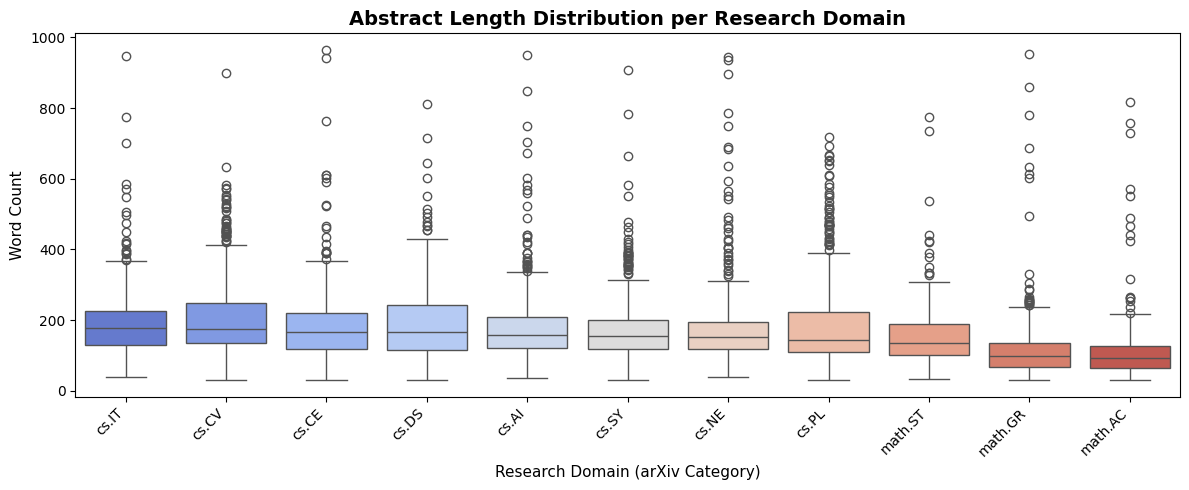

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=final_df,
    x='category',
    y='word_count',
    order=final_df.groupby('category')['word_count'].median().sort_values(ascending=False).index,
    palette='coolwarm'
)
plt.title('Abstract Length Distribution per Research Domain', fontsize=14, fontweight='bold')
plt.xlabel('Research Domain (arXiv Category)', fontsize=11)
plt.ylabel('Word Count', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda1_abstract_length_per_category.png', dpi=150)
plt.show()

<H3><b>PLOT 2

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


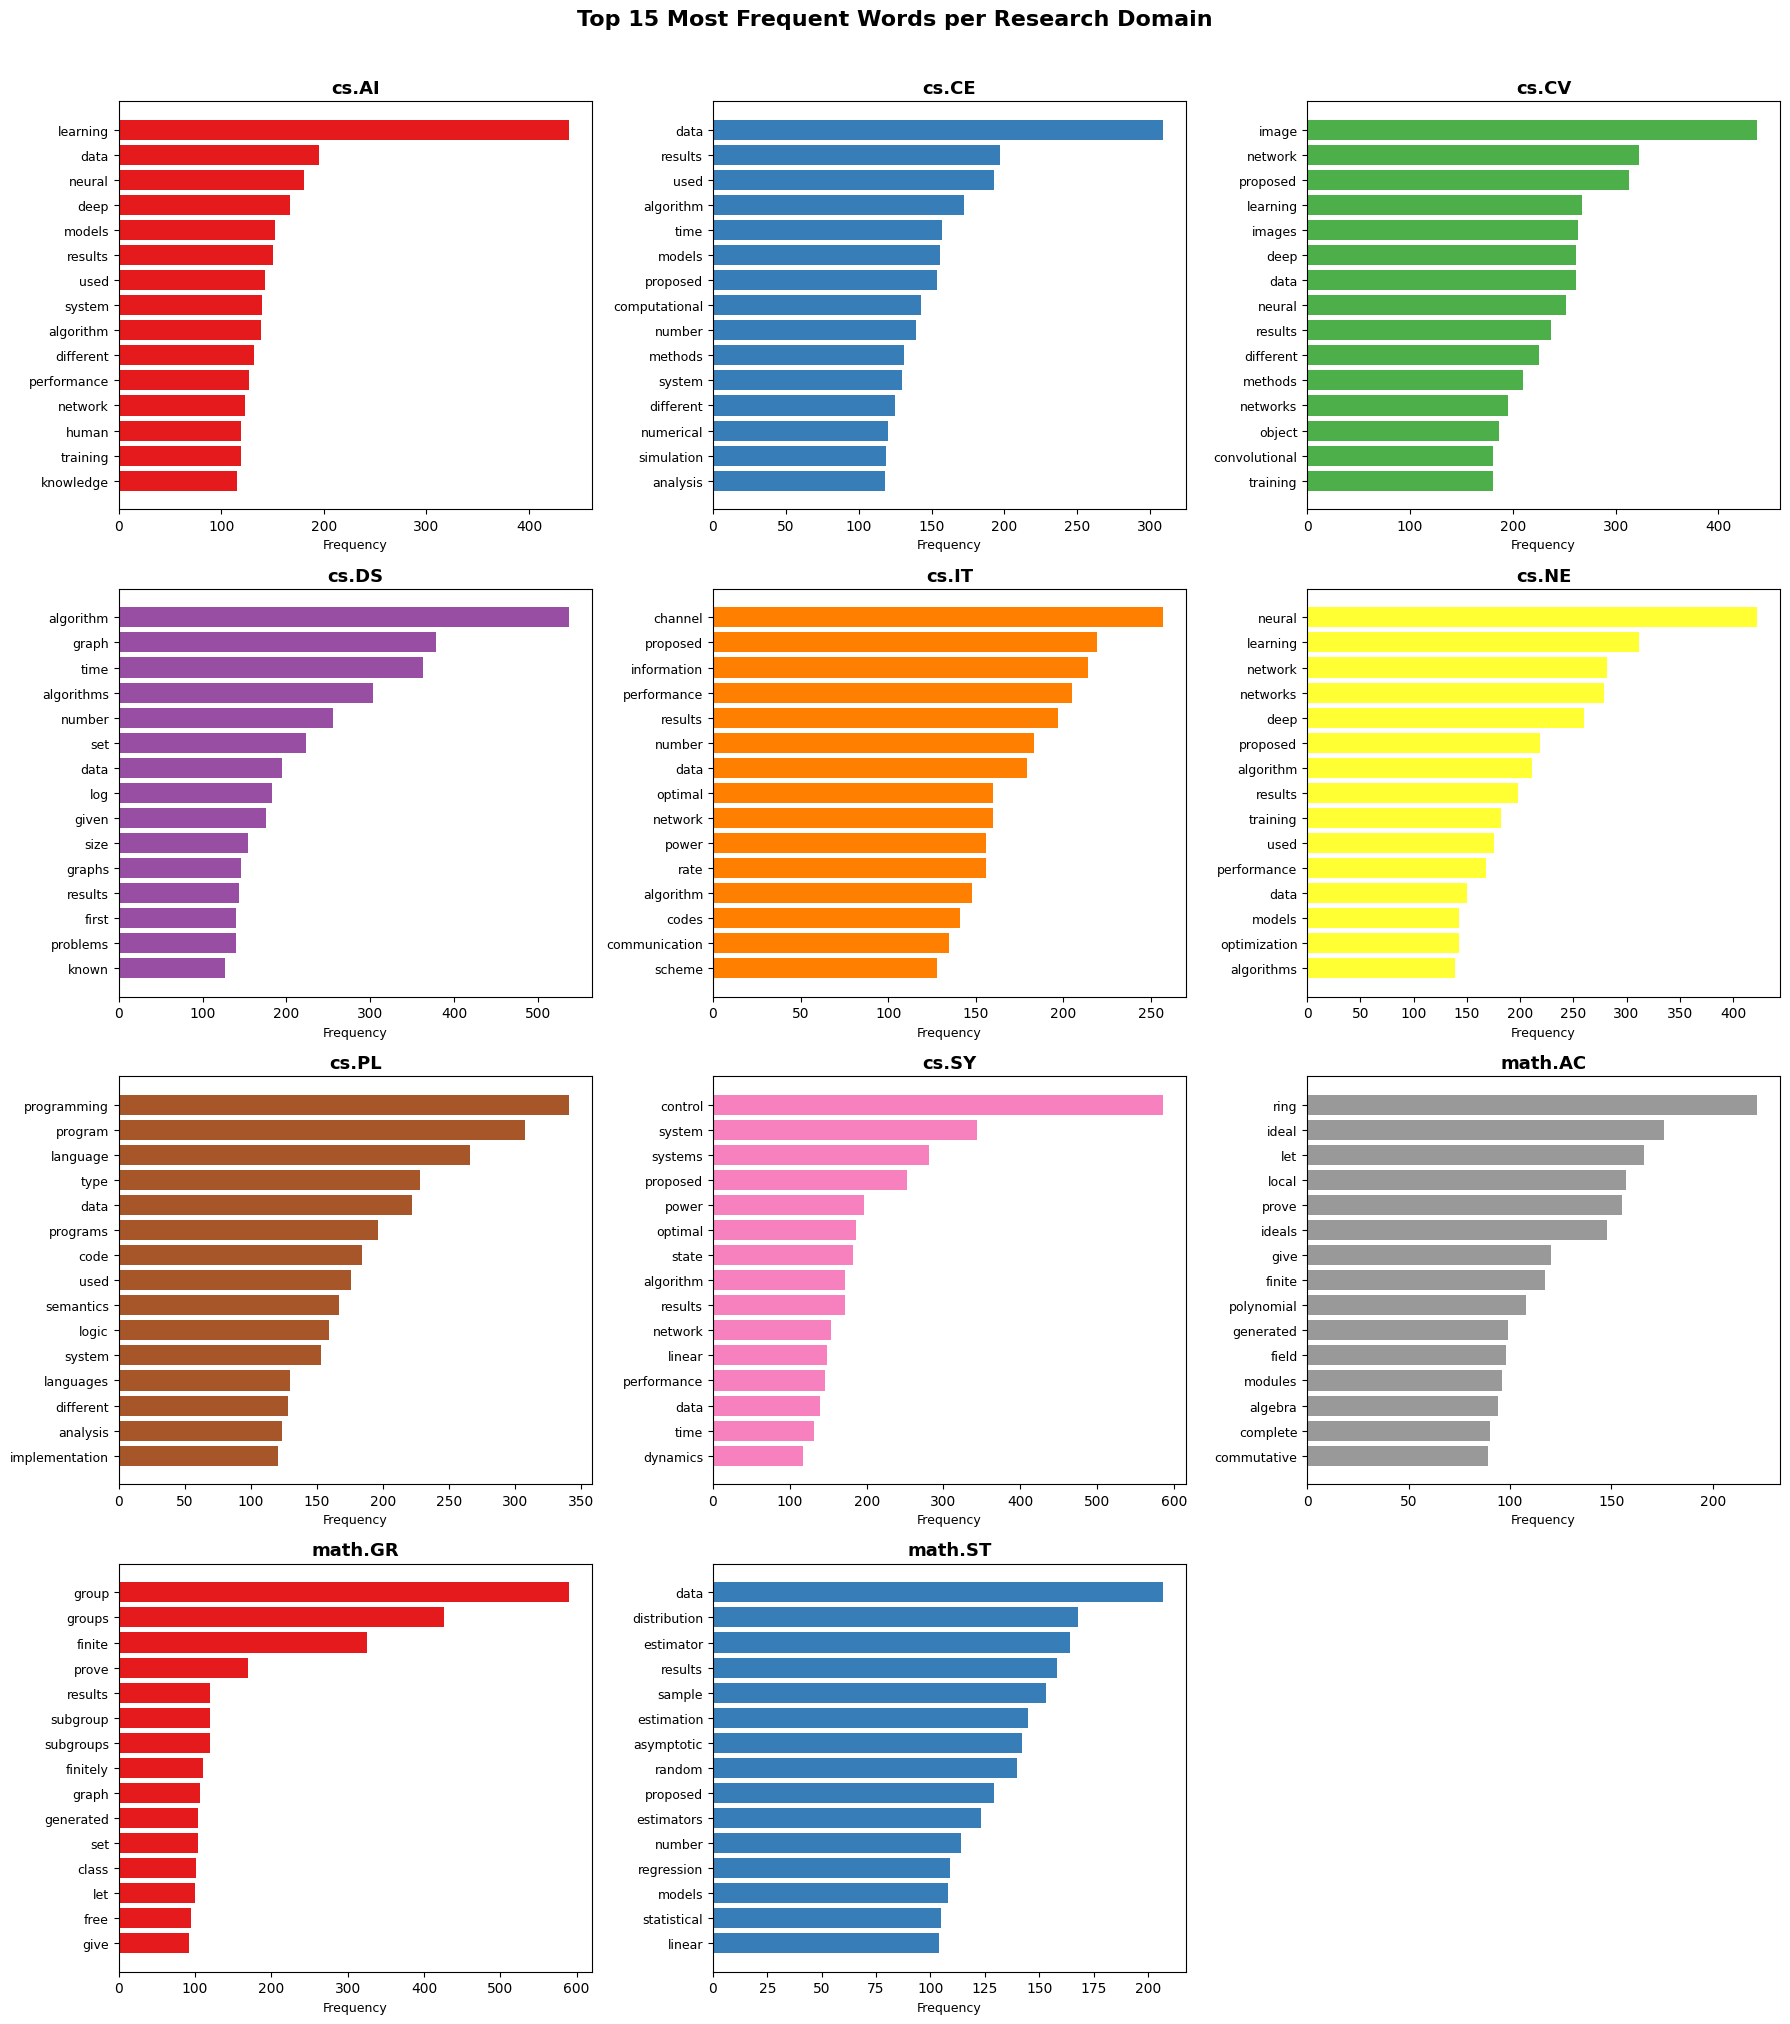

In [19]:
from collections import Counter
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Add domain-generic words that appear everywhere and carry no discriminative signal
custom_stop = {'paper', 'propose', 'show', 'result', 'method', 'approach',
               'problem', 'based', 'using', 'also', 'two', 'one', 'new',
               'present', 'work', 'model', 'use', 'study', 'consider'}

all_stops = stop_words.union(custom_stop)

def get_top_words(texts, n=15):
    words = []
    for text in texts:
        tokens = str(text).lower().split()
        tokens = [t for t in tokens if t.isalpha() and t not in all_stops and len(t) > 2]
        words.extend(tokens)
    return Counter(words).most_common(n)

# ---- Plot ----
categories = final_df['category'].unique()
n_cats = len(categories)

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, cat in enumerate(sorted(categories)):
    texts = final_df[final_df['category'] == cat]['abstract']
    top_words = get_top_words(texts)
    words, counts = zip(*top_words)

    axes[i].barh(words[::-1], counts[::-1], color=sns.color_palette('Set1', n_cats)[i])
    axes[i].set_title(f'{cat}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Frequency', fontsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

# Hide the 12th subplot (we have 11 categories, 4x3 grid = 12 slots)
axes[11].set_visible(False)

plt.suptitle('Top 15 Most Frequent Words per Research Domain',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda2_top_words_per_category.png', dpi=150, bbox_inches='tight')
plt.show()

<H3><b>PLOT 3

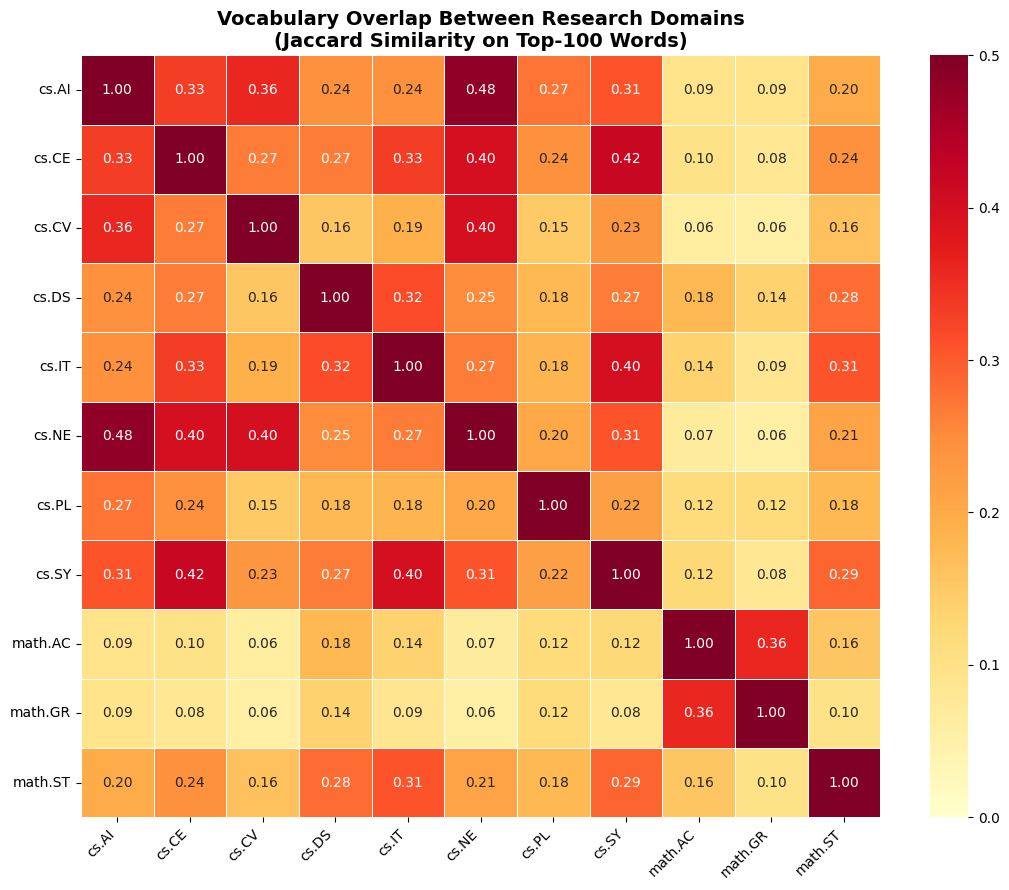

In [20]:
import numpy as np

def get_top_n_vocab(texts, n=100):
    words = []
    for text in texts:
        tokens = str(text).lower().split()
        tokens = [t for t in tokens if t.isalpha()
                  and t not in all_stops
                  and len(t) > 2]
        words.extend(tokens)
    return set([w for w, _ in Counter(words).most_common(n)])

# Build top-100 vocabulary set per category
categories_sorted = sorted(final_df['category'].unique())
vocab_per_cat = {
    cat: get_top_n_vocab(final_df[final_df['category'] == cat]['abstract'])
    for cat in categories_sorted
}

# Compute pairwise Jaccard similarity: |A ∩ B| / |A ∪ B|
n = len(categories_sorted)
overlap_matrix = np.zeros((n, n))

for i, cat1 in enumerate(categories_sorted):
    for j, cat2 in enumerate(categories_sorted):
        set1 = vocab_per_cat[cat1]
        set2 = vocab_per_cat[cat2]
        intersection = len(set1 & set2)
        union = len(set1 | set2)
        overlap_matrix[i][j] = intersection / union if union > 0 else 0

# ---- Plot ----
plt.figure(figsize=(11, 9))
sns.heatmap(
    overlap_matrix,
    xticklabels=categories_sorted,
    yticklabels=categories_sorted,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    vmin=0, vmax=0.5
)
plt.title('Vocabulary Overlap Between Research Domains\n(Jaccard Similarity on Top-100 Words)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('eda3_vocabulary_overlap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

<H3><B> PLOT 4

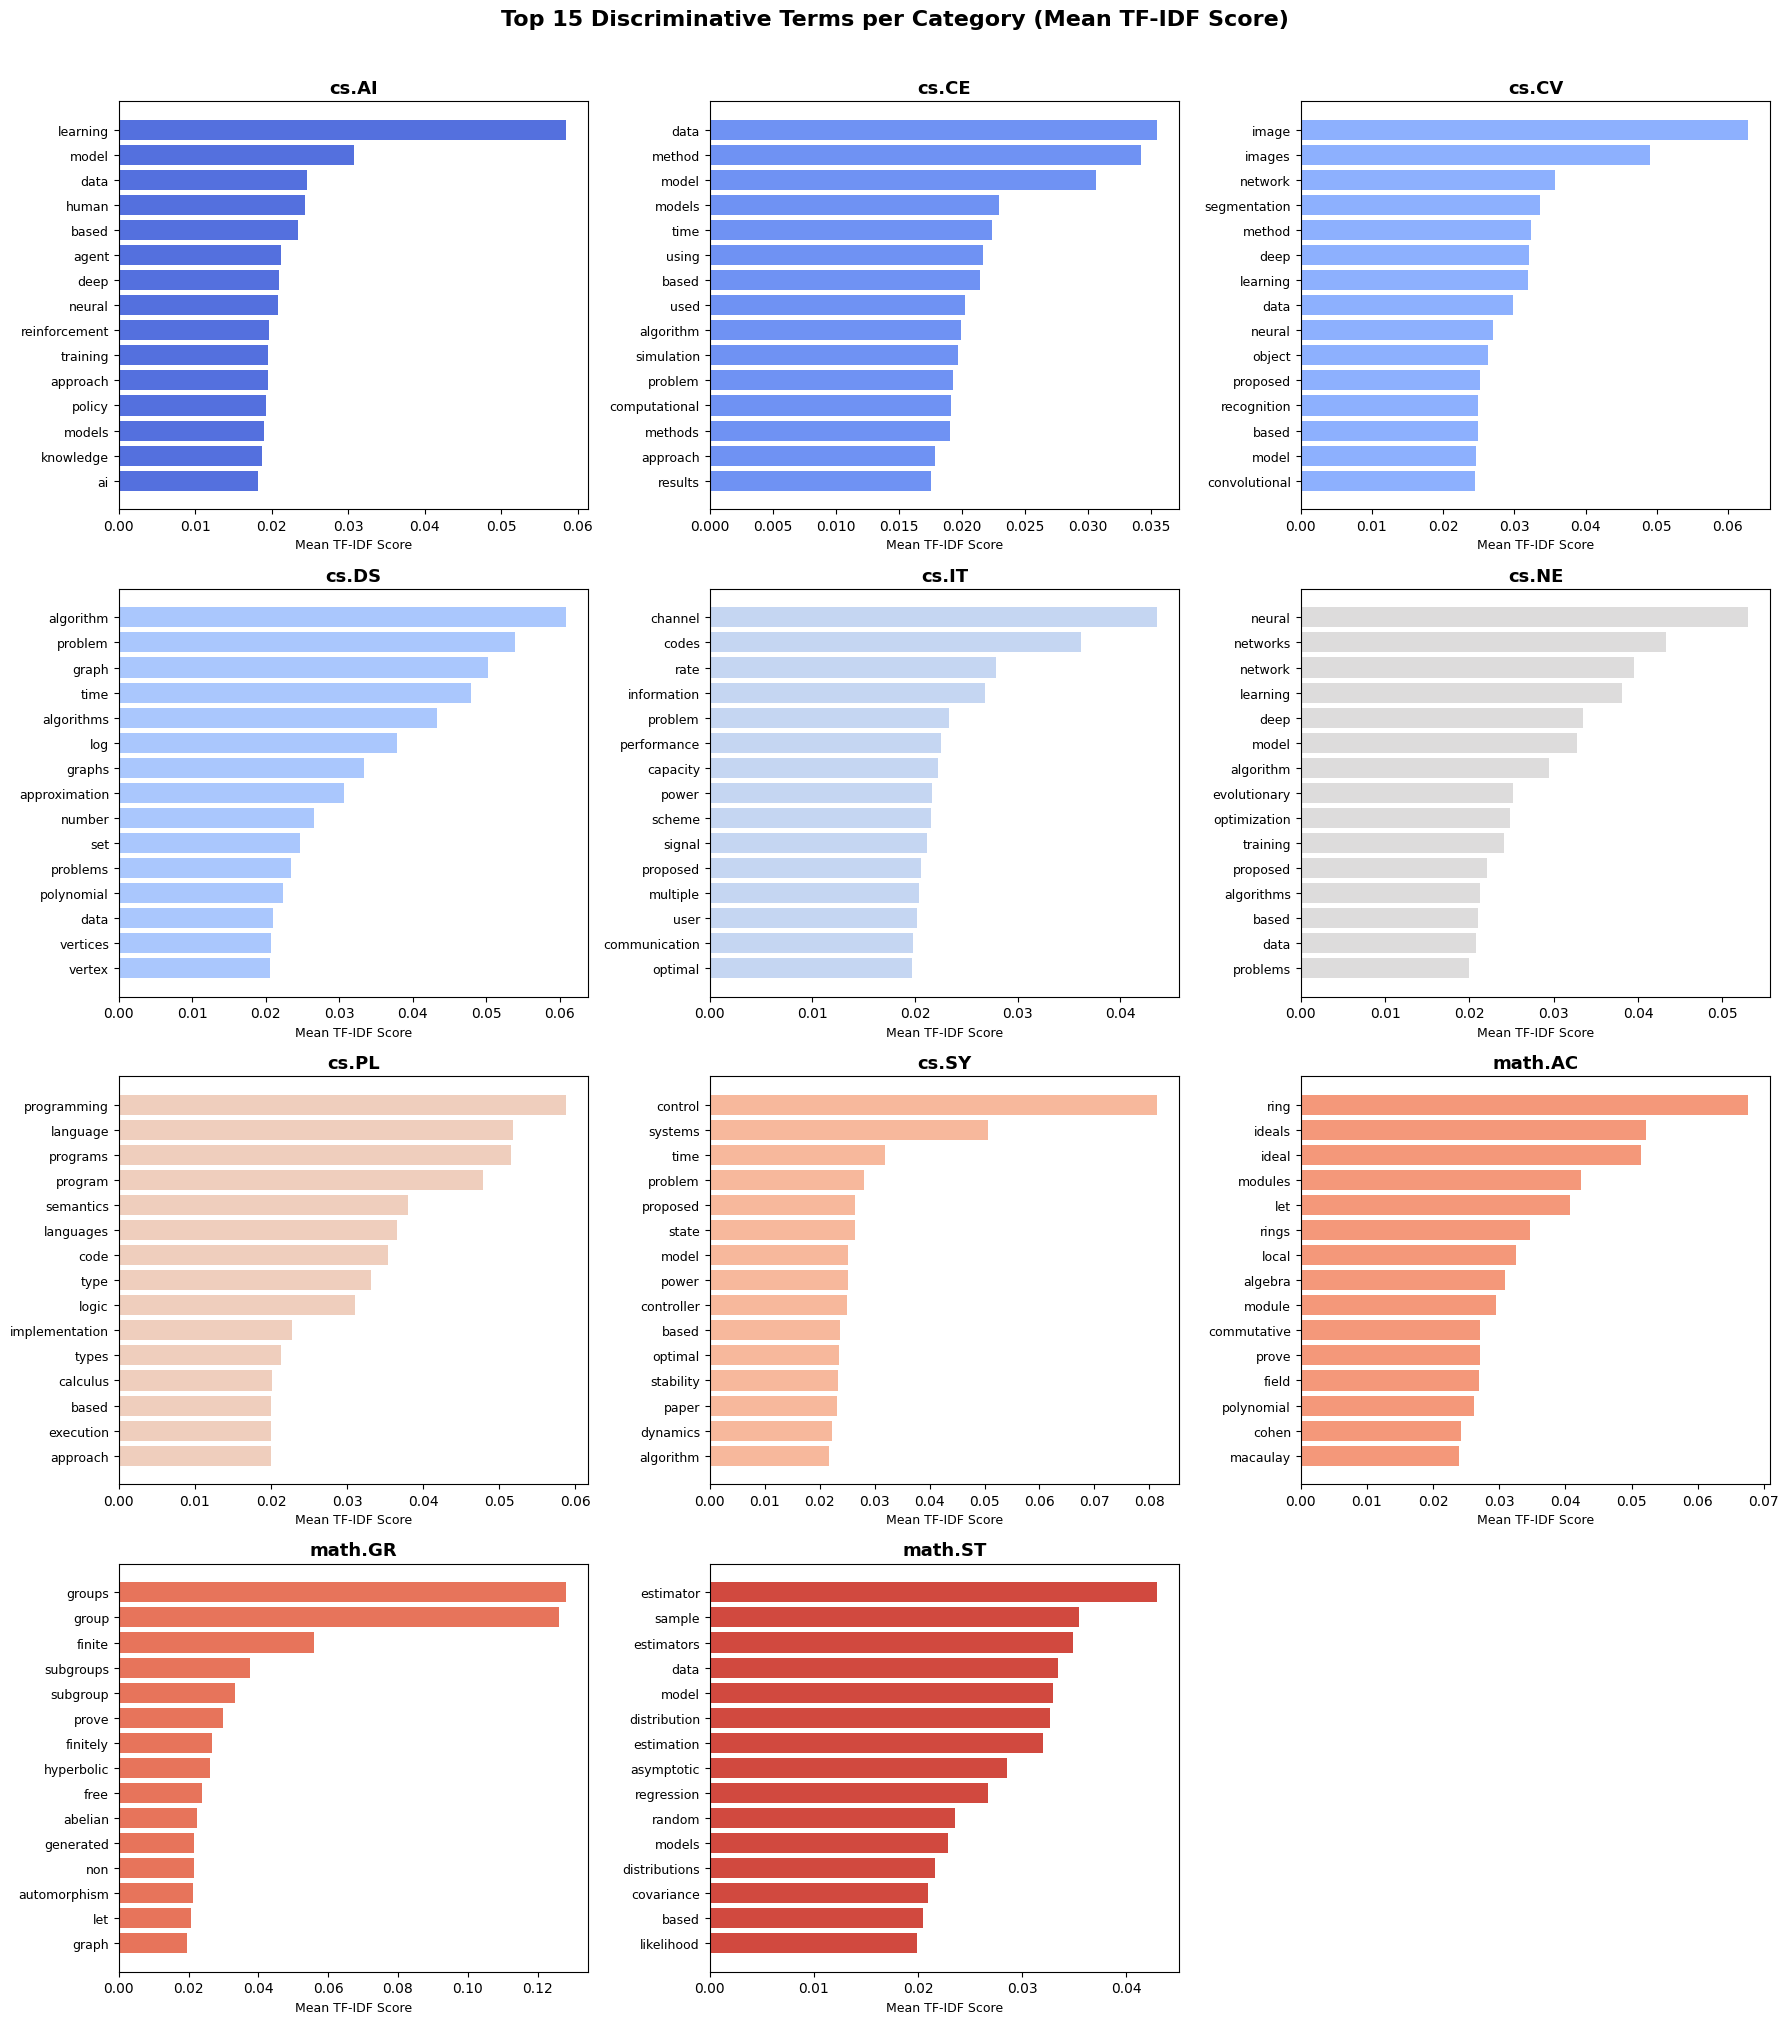

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Fit TF-IDF on the full dataset
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,1))
X = tfidf.fit_transform(final_df['abstract'])
feature_names = np.array(tfidf.get_feature_names_out())

categories_sorted = sorted(final_df['category'].unique())

# For each category, compute mean TF-IDF score per term across all docs in that category
# High mean score = this term is both frequent AND distinctive for this category
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, cat in enumerate(categories_sorted):
    cat_indices = final_df[final_df['category'] == cat].index
    cat_tfidf = X[cat_indices].toarray()
    mean_scores = cat_tfidf.mean(axis=0)
    top_indices = mean_scores.argsort()[-15:][::-1]
    top_terms = feature_names[top_indices]
    top_scores = mean_scores[top_indices]

    axes[i].barh(top_terms[::-1], top_scores[::-1],
                 color=sns.color_palette('coolwarm', len(categories_sorted))[i])
    axes[i].set_title(f'{cat}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Mean TF-IDF Score', fontsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

axes[11].set_visible(False)

plt.suptitle('Top 15 Discriminative Terms per Category (Mean TF-IDF Score)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda4_tfidf_discriminative_terms.png', dpi=150, bbox_inches='tight')
plt.show()

<H3><B> PLOT 5

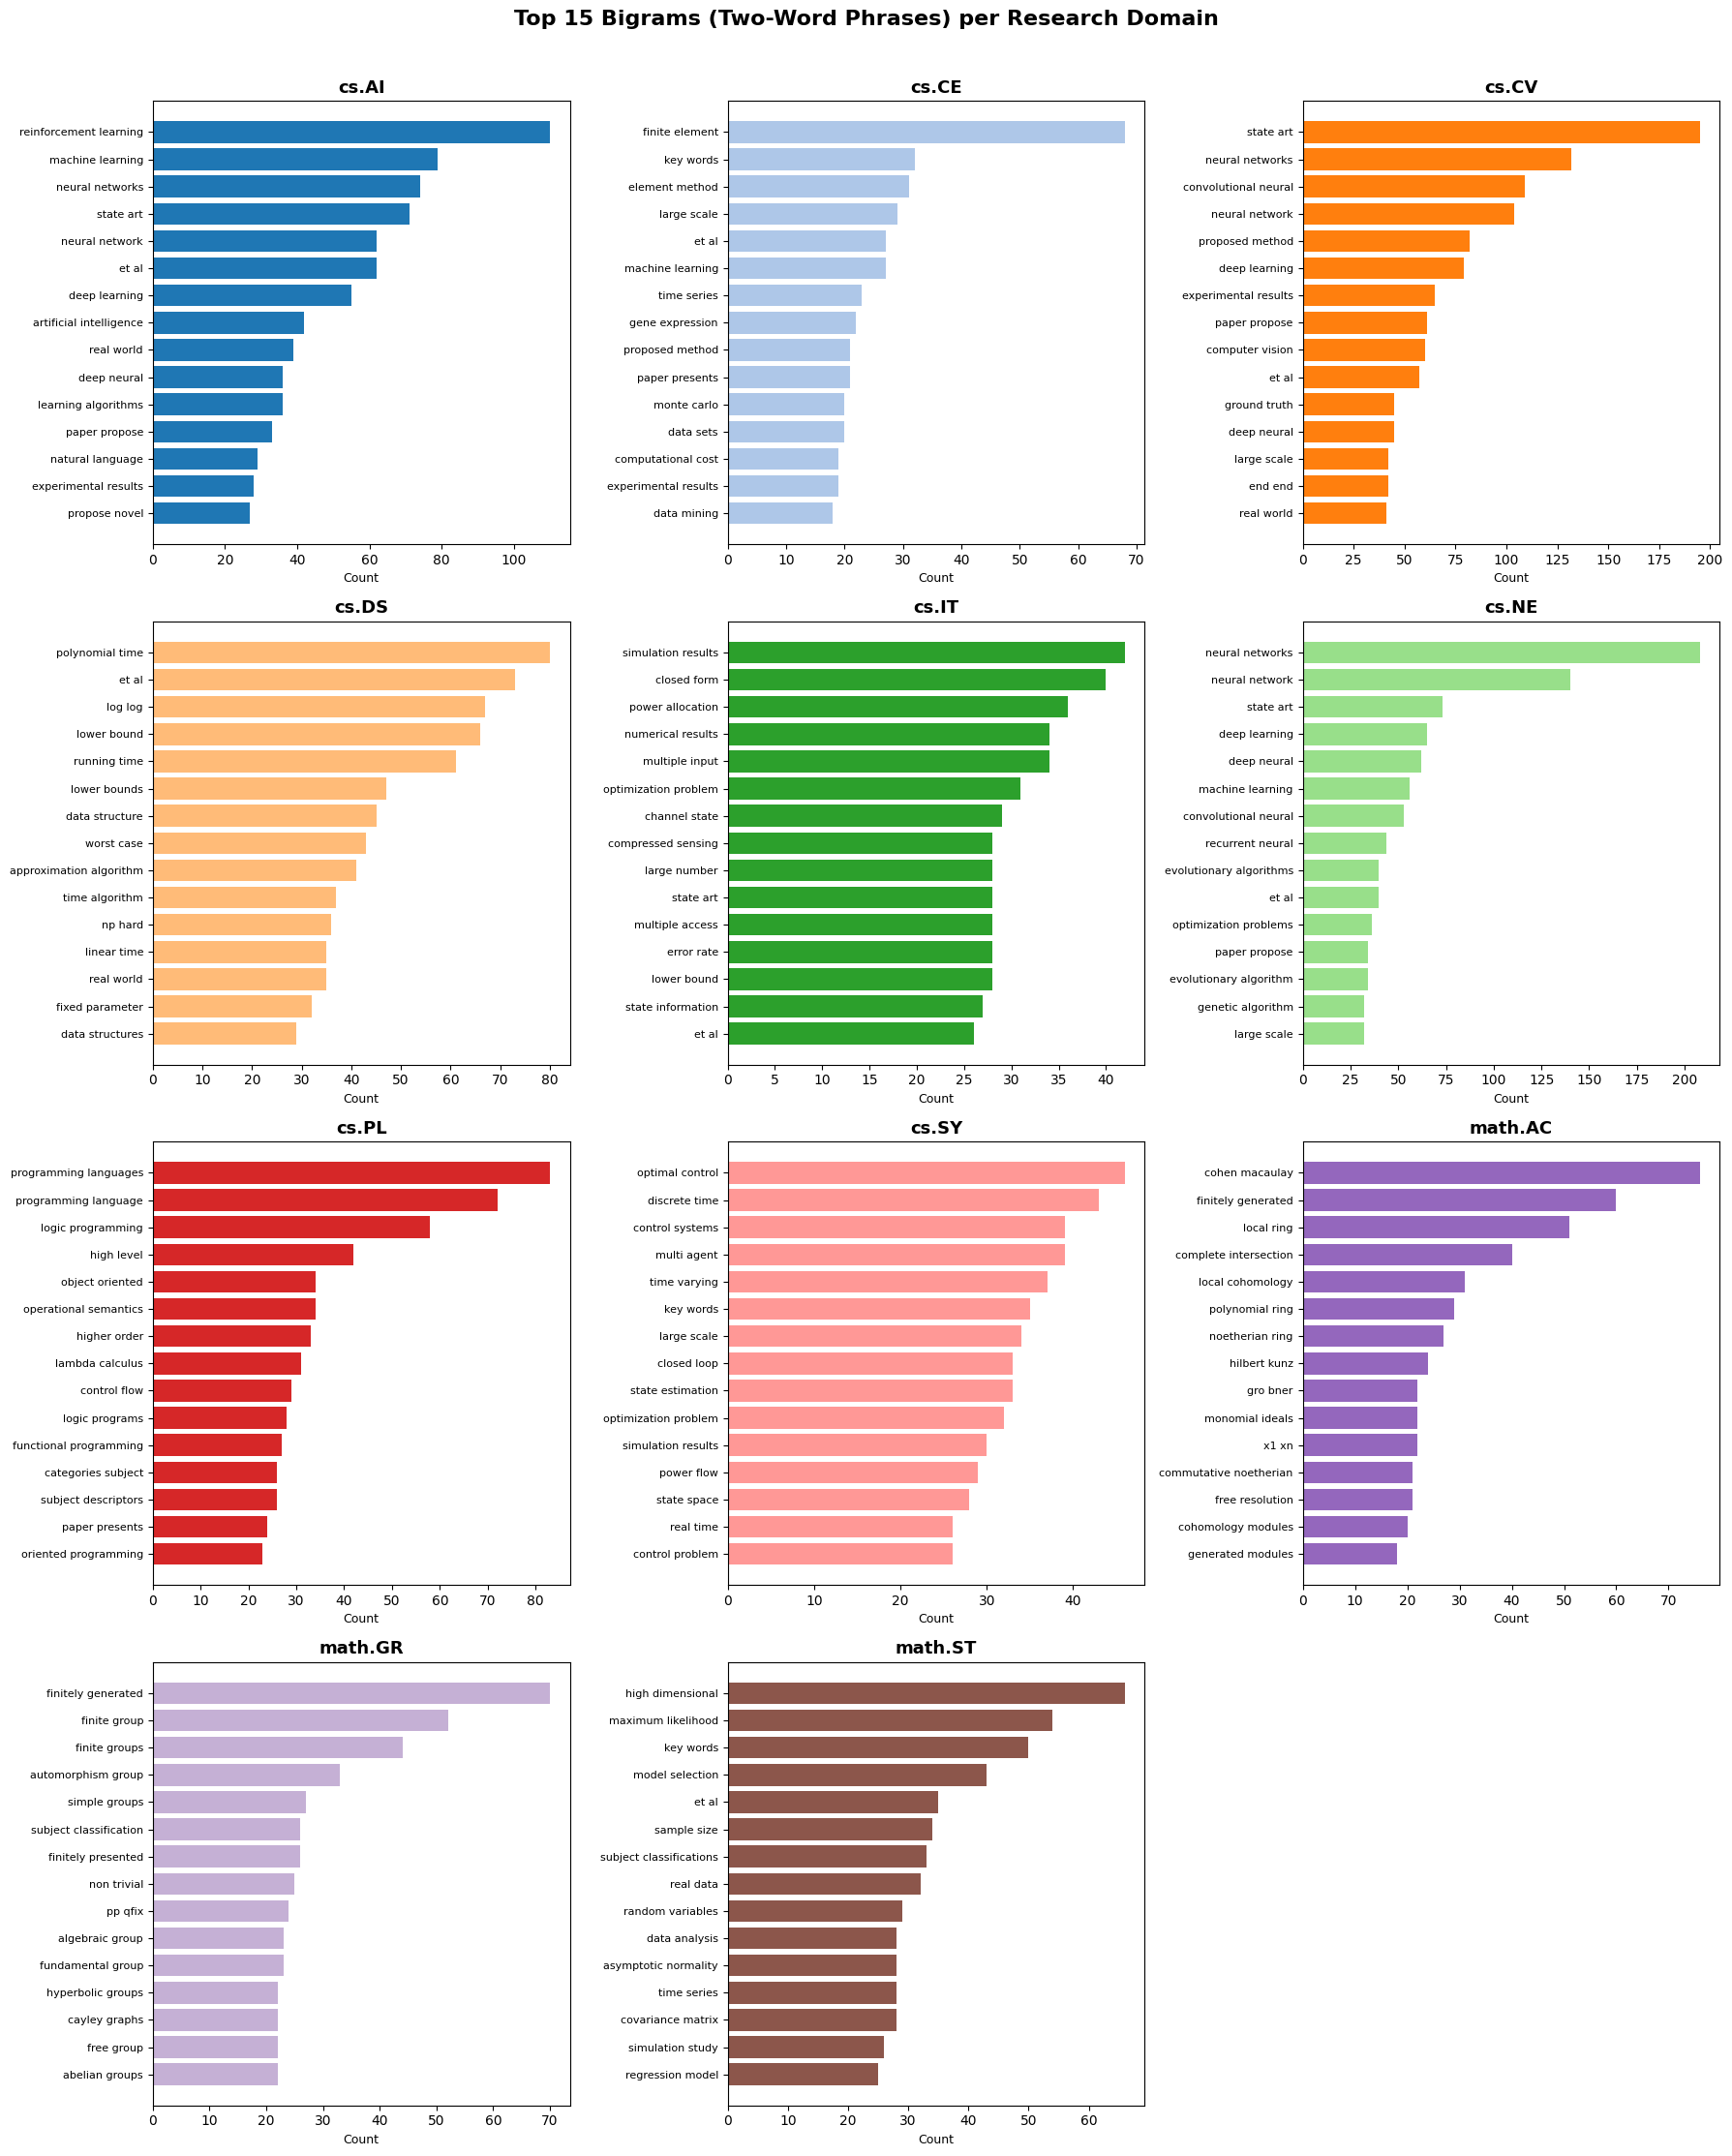

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

categories_sorted = sorted(final_df['category'].unique())

fig, axes = plt.subplots(4, 3, figsize=(18, 22))
axes = axes.flatten()

for i, cat in enumerate(categories_sorted):
    texts = final_df[final_df['category'] == cat]['abstract'].tolist()

    # Extract bigrams
    vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        stop_words='english',
        max_features=10000
    )
    X_bigram = vectorizer.fit_transform(texts)
    bigram_names = vectorizer.get_feature_names_out()
    bigram_counts = X_bigram.sum(axis=0).A1

    # Get top 15
    top_indices = bigram_counts.argsort()[-15:][::-1]
    top_bigrams = bigram_names[top_indices]
    top_counts = bigram_counts[top_indices]

    axes[i].barh(top_bigrams[::-1], top_counts[::-1],
                 color=sns.color_palette('tab20', len(categories_sorted))[i])
    axes[i].set_title(f'{cat}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Count', fontsize=9)
    axes[i].tick_params(axis='y', labelsize=8)

axes[11].set_visible(False)

plt.suptitle('Top 15 Bigrams (Two-Word Phrases) per Research Domain',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda5_bigrams_per_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Add to your preprocessing pipeline in Step 10
CUSTOM_PHRASE_STOP = [
    'et al', 'paper presents', 'paper propose', 'propose novel',
    'proposed method', 'experimental results', 'simulation results',
    'large scale', 'real world', 'state art', 'end end',
    'key words', 'subject classifications', 'subject descriptors',
    'paper proposes', 'et al.', 'pp qfix'
]

def remove_filler_phrases(text):
    text = str(text).lower()
    for phrase in CUSTOM_PHRASE_STOP:
        text = text.replace(phrase, '')
    return text

final_df['abstract_filtered'] = final_df['abstract'].apply(remove_filler_phrases)

<H3><B> PLOT 6

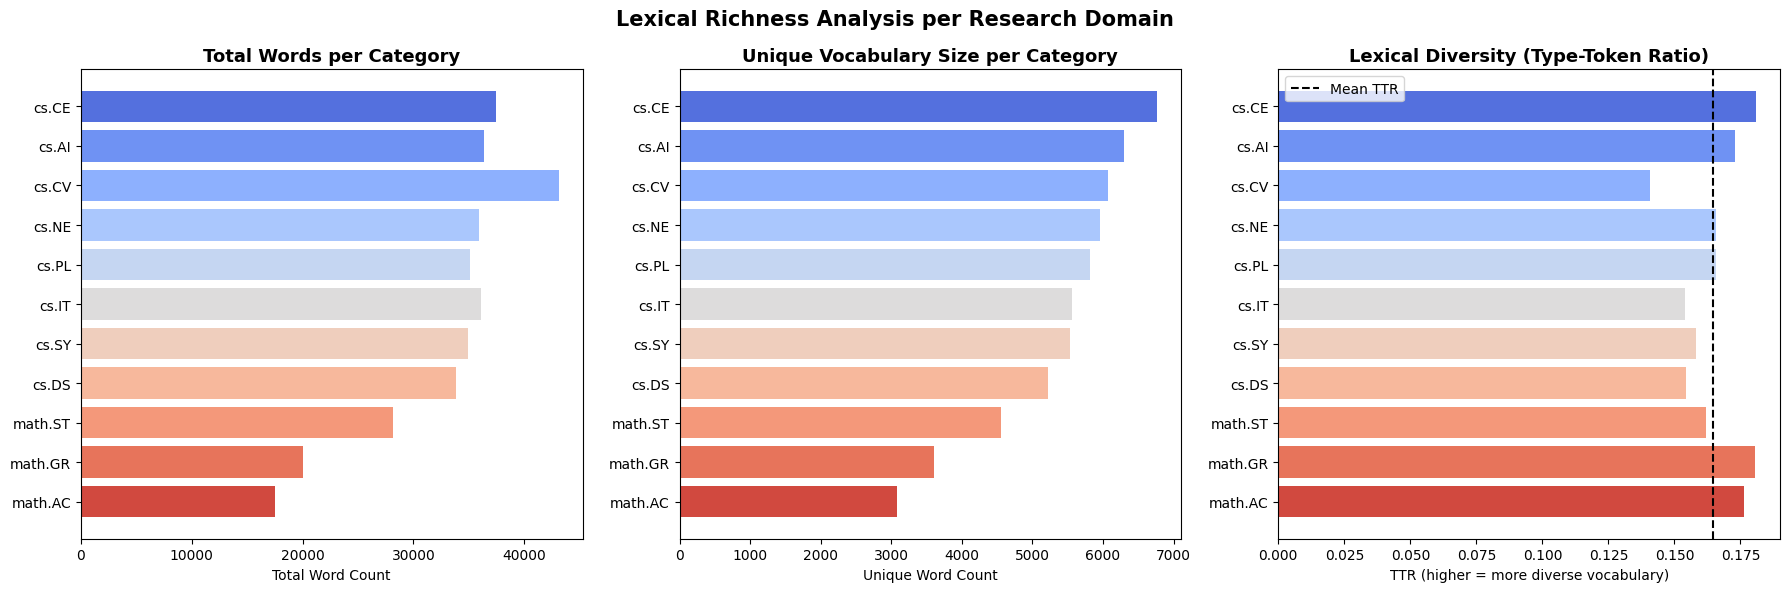


Lexical Stats Table:
category  total_words  unique_words      ttr
   cs.CE        37423          6771 0.180932
   cs.AI        36404          6297 0.172975
   cs.CV        43100          6070 0.140835
   cs.NE        35957          5955 0.165614
   cs.PL        35097          5813 0.165627
   cs.IT        36135          5566 0.154033
   cs.SY        34957          5526 0.158080
   cs.DS        33820          5224 0.154465
 math.ST        28163          4557 0.161808
 math.GR        20008          3610 0.180428
 math.AC        17492          3085 0.176366


In [24]:
# ==========================================
# EDA PLOT 6: UNIQUE VOCABULARY SIZE PER CATEGORY
# ==========================================

def get_vocab_stats(texts):
    all_words = []
    for text in texts:
        tokens = str(text).lower().split()
        tokens = [t for t in tokens if t.isalpha() and t not in all_stops and len(t) > 2]
        all_words.extend(tokens)
    total_words = len(all_words)
    unique_words = len(set(all_words))
    # Type-Token Ratio (TTR) = unique / total, measures lexical diversity
    ttr = unique_words / total_words if total_words > 0 else 0
    return total_words, unique_words, ttr

categories_sorted = sorted(final_df['category'].unique())
stats = []
for cat in categories_sorted:
    texts = final_df[final_df['category'] == cat]['abstract']
    total, unique, ttr = get_vocab_stats(texts)
    stats.append({'category': cat, 'total_words': total,
                  'unique_words': unique, 'ttr': ttr})

stats_df = pd.DataFrame(stats).sort_values('unique_words', ascending=False)

# ---- Plot: 3 subplots side by side ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Total word count per category
axes[0].barh(stats_df['category'], stats_df['total_words'],
             color=sns.color_palette('coolwarm', len(stats_df)))
axes[0].set_title('Total Words per Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Word Count')
axes[0].invert_yaxis()

# 2. Unique vocabulary size per category
axes[1].barh(stats_df['category'], stats_df['unique_words'],
             color=sns.color_palette('coolwarm', len(stats_df)))
axes[1].set_title('Unique Vocabulary Size per Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Unique Word Count')
axes[1].invert_yaxis()

# 3. Type-Token Ratio (lexical diversity)
axes[2].barh(stats_df['category'], stats_df['ttr'],
             color=sns.color_palette('coolwarm', len(stats_df)))
axes[2].set_title('Lexical Diversity (Type-Token Ratio)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('TTR (higher = more diverse vocabulary)')
axes[2].invert_yaxis()
axes[2].axvline(x=stats_df['ttr'].mean(), color='black',
                linestyle='--', linewidth=1.5, label='Mean TTR')
axes[2].legend()

plt.suptitle('Lexical Richness Analysis per Research Domain',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda6_lexical_richness.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLexical Stats Table:")
print(stats_df.to_string(index=False))

<H3><B> PLOT 7

Total unique terms in matrix: 67


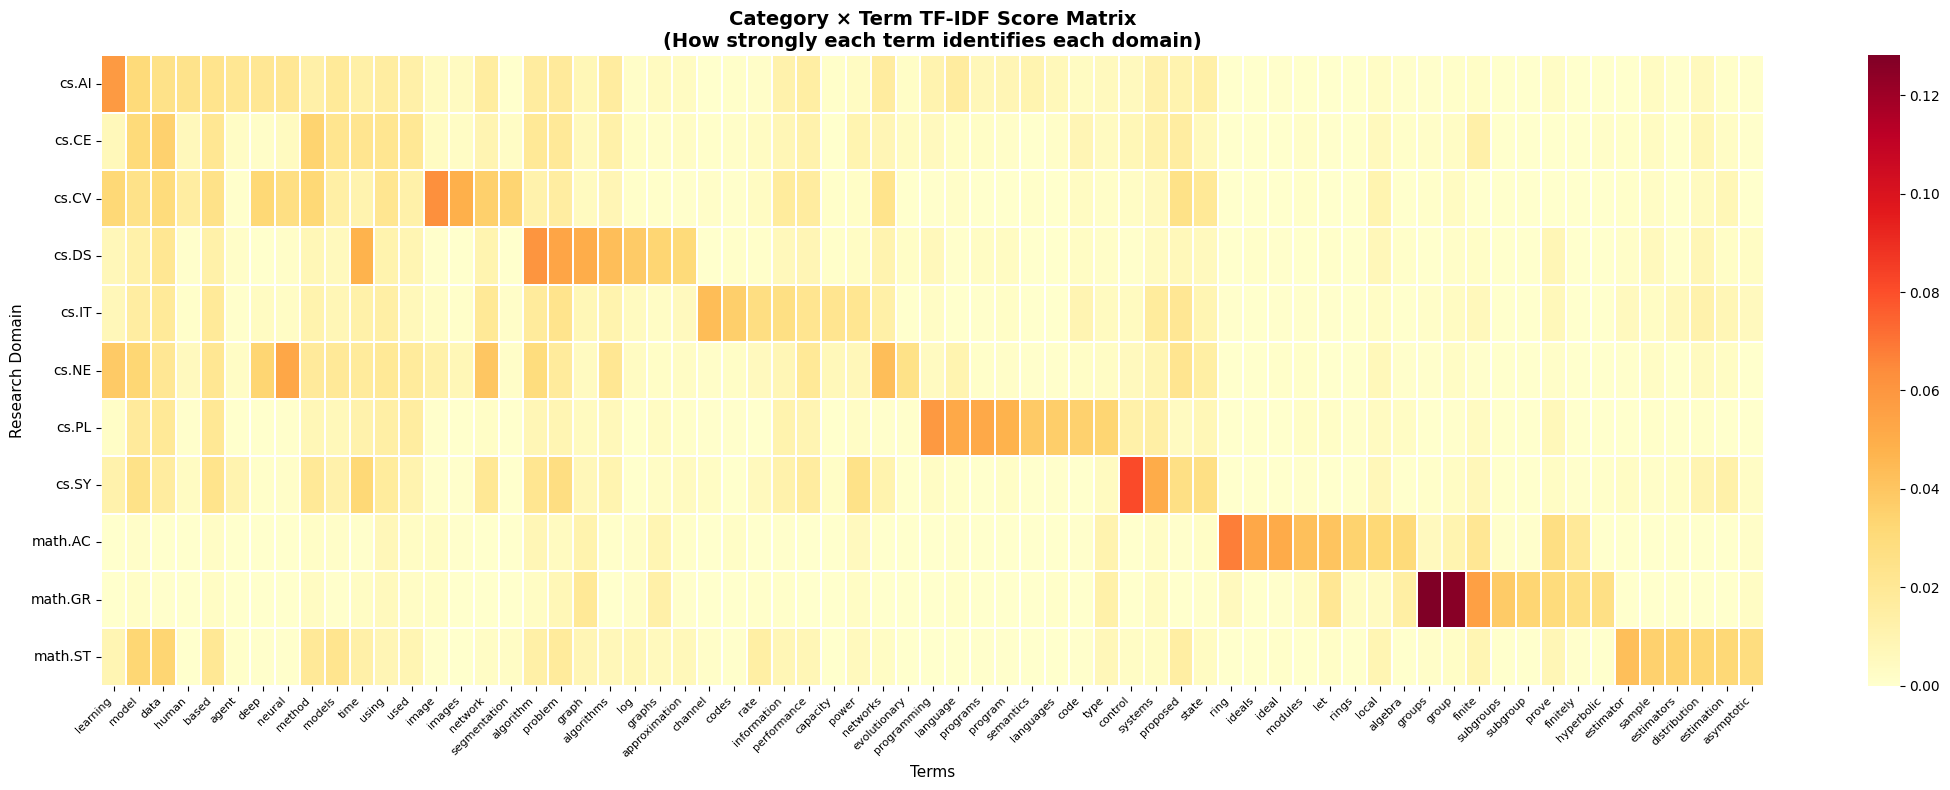

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

categories_sorted = sorted(final_df['category'].unique())

# Get top 10 discriminative terms per category from TF-IDF (same as Plot 4)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,1))
X = tfidf.fit_transform(final_df['abstract'])
feature_names = np.array(tfidf.get_feature_names_out())

# Collect top 8 terms per category (keeping it tight for readability)
top_terms_per_cat = {}
for cat in categories_sorted:
    cat_indices = final_df[final_df['category'] == cat].index
    cat_tfidf = X[cat_indices].toarray()
    mean_scores = cat_tfidf.mean(axis=0)
    top_idx = mean_scores.argsort()[-8:][::-1]
    top_terms_per_cat[cat] = list(feature_names[top_idx])

# Build union of all selected terms
all_selected_terms = []
for terms in top_terms_per_cat.values():
    for t in terms:
        if t not in all_selected_terms:
            all_selected_terms.append(t)

print(f"Total unique terms in matrix: {len(all_selected_terms)}")

# Build matrix: rows = categories, columns = terms
# Value = mean TF-IDF score of that term in that category
matrix = np.zeros((len(categories_sorted), len(all_selected_terms)))
for i, cat in enumerate(categories_sorted):
    cat_indices = final_df[final_df['category'] == cat].index
    cat_tfidf = X[cat_indices].toarray()
    mean_scores = cat_tfidf.mean(axis=0)
    for j, term in enumerate(all_selected_terms):
        if term in feature_names:
            term_idx = np.where(feature_names == term)[0][0]
            matrix[i][j] = mean_scores[term_idx]

# ---- Plot ----
plt.figure(figsize=(22, 8))
sns.heatmap(
    matrix,
    xticklabels=all_selected_terms,
    yticklabels=categories_sorted,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    annot=False
)
plt.title('Category × Term TF-IDF Score Matrix\n(How strongly each term identifies each domain)',
          fontsize=14, fontweight='bold')
plt.xlabel('Terms', fontsize=11)
plt.ylabel('Research Domain', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('eda7_category_term_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

<H3><B> PLOT 8

In [26]:
!pip install wordcloud -q

from wordcloud import WordCloud
import matplotlib.pyplot as plt

categories_sorted = sorted(final_df['category'].unique())

fig, axes = plt.subplots(4, 3, figsize=(20, 22))
axes = axes.flatten()

# Use a different color palette per category for visual distinction
colormaps = [
    'Blues', 'Oranges', 'Greens', 'Purples', 'YlOrBr',
    'RdPu', 'BuGn', 'OrRd', 'PuBu', 'YlGn', 'RdYlBu'
]

for i, cat in enumerate(categories_sorted):
    texts = final_df[final_df['category'] == cat]['abstract'].tolist()
    combined_text = " ".join([str(t) for t in texts])

    # Remove filler phrases before generating
    for phrase in CUSTOM_PHRASE_STOP:
        combined_text = combined_text.lower().replace(phrase, '')

    wc = WordCloud(
        width=600,
        height=400,
        background_color='white',
        stopwords=all_stops,
        colormap=colormaps[i],
        max_words=80,
        min_font_size=8,
        collocations=True,  # captures bigrams naturally
        prefer_horizontal=0.85
    ).generate(combined_text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{cat}', fontsize=14, fontweight='bold', pad=10)
    axes[i].axis('off')

axes[11].axis('off')

plt.suptitle('Word Clouds per Research Domain\n(Size = frequency + distinctiveness)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda8_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

<H3><B> PLOT 9

/tmp/ipykernel_2385/1765032776.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_2385/1765032776.py:32: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


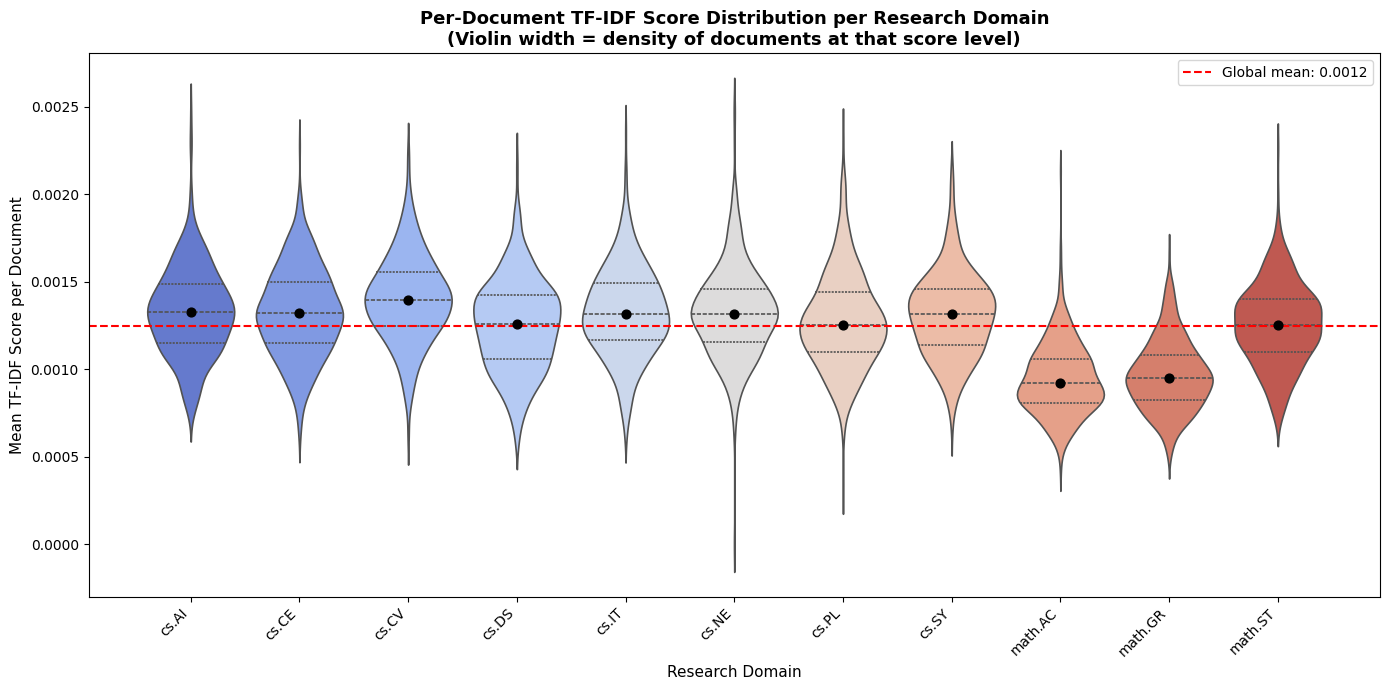


Per-category TF-IDF score summary:
          count     mean      std      min      25%      50%      75%      max
category                                                                      
cs.AI     447.0  0.00133  0.00026  0.00074  0.00115  0.00133  0.00149  0.00248
cs.CE     449.0  0.00133  0.00025  0.00062  0.00115  0.00132  0.00150  0.00228
cs.CV     442.0  0.00140  0.00025  0.00060  0.00125  0.00140  0.00155  0.00226
cs.DS     444.0  0.00125  0.00026  0.00059  0.00106  0.00126  0.00143  0.00220
cs.IT     433.0  0.00133  0.00026  0.00062  0.00117  0.00132  0.00149  0.00236
cs.NE     442.0  0.00133  0.00026  0.00000  0.00116  0.00132  0.00146  0.00251
cs.PL     417.0  0.00128  0.00027  0.00034  0.00110  0.00125  0.00144  0.00233
cs.SY     441.0  0.00131  0.00024  0.00065  0.00114  0.00132  0.00146  0.00216
math.AC   446.0  0.00095  0.00020  0.00043  0.00081  0.00092  0.00106  0.00213
math.GR   443.0  0.00097  0.00020  0.00049  0.00083  0.00095  0.00108  0.00166
math.ST   440.0 

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Fit TF-IDF on full dataset
tfidf_v = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 1)
)
X_tfidf = tfidf_v.fit_transform(final_df['abstract'])
feature_names = np.array(tfidf_v.get_feature_names_out())

# For each category get the mean TF-IDF score per document
# (document-level mean score = how "rich" each document is in discriminative terms)
categories_sorted = sorted(final_df['category'].unique())

violin_data = []
for cat in categories_sorted:
    cat_indices = final_df[final_df['category'] == cat].index
    cat_matrix = X_tfidf[cat_indices].toarray()

    # Mean TF-IDF score per document (across all 5000 features)
    doc_mean_scores = cat_matrix.mean(axis=1)

    for score in doc_mean_scores:
        violin_data.append({'category': cat, 'mean_tfidf_score': score})

violin_df = pd.DataFrame(violin_data)

# ---- Plot ----
plt.figure(figsize=(14, 7))
ax = sns.violinplot(
    data=violin_df,
    x='category',
    y='mean_tfidf_score',
    order=sorted(categories_sorted),
    palette='coolwarm',
    inner='quartile',    # shows median + IQR inside violin
    scale='width',       # all violins same width for comparability
    linewidth=1.2
)

# Overlay individual category medians as points
medians = violin_df.groupby('category')['mean_tfidf_score'].median()
for i, cat in enumerate(sorted(categories_sorted)):
    plt.scatter(i, medians[cat], color='black', s=40, zorder=5)

plt.title('Per-Document TF-IDF Score Distribution per Research Domain\n(Violin width = density of documents at that score level)',
          fontsize=13, fontweight='bold')
plt.xlabel('Research Domain', fontsize=11)
plt.ylabel('Mean TF-IDF Score per Document', fontsize=11)
plt.xticks(rotation=45, ha='right')

# Add mean line across all categories
global_mean = violin_df['mean_tfidf_score'].mean()
plt.axhline(y=global_mean, color='red', linestyle='--',
            linewidth=1.5, label=f'Global mean: {global_mean:.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('eda9_tfidf_violin.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print("\nPer-category TF-IDF score summary:")
print(violin_df.groupby('category')['mean_tfidf_score'].describe().round(5))

<H3><B> PRE-PROCESSING + PLOT 10

This cell runs the full preprocessing pipeline AND generates the validation plot

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


⚙️ Running preprocessing pipeline...
✅ Done.


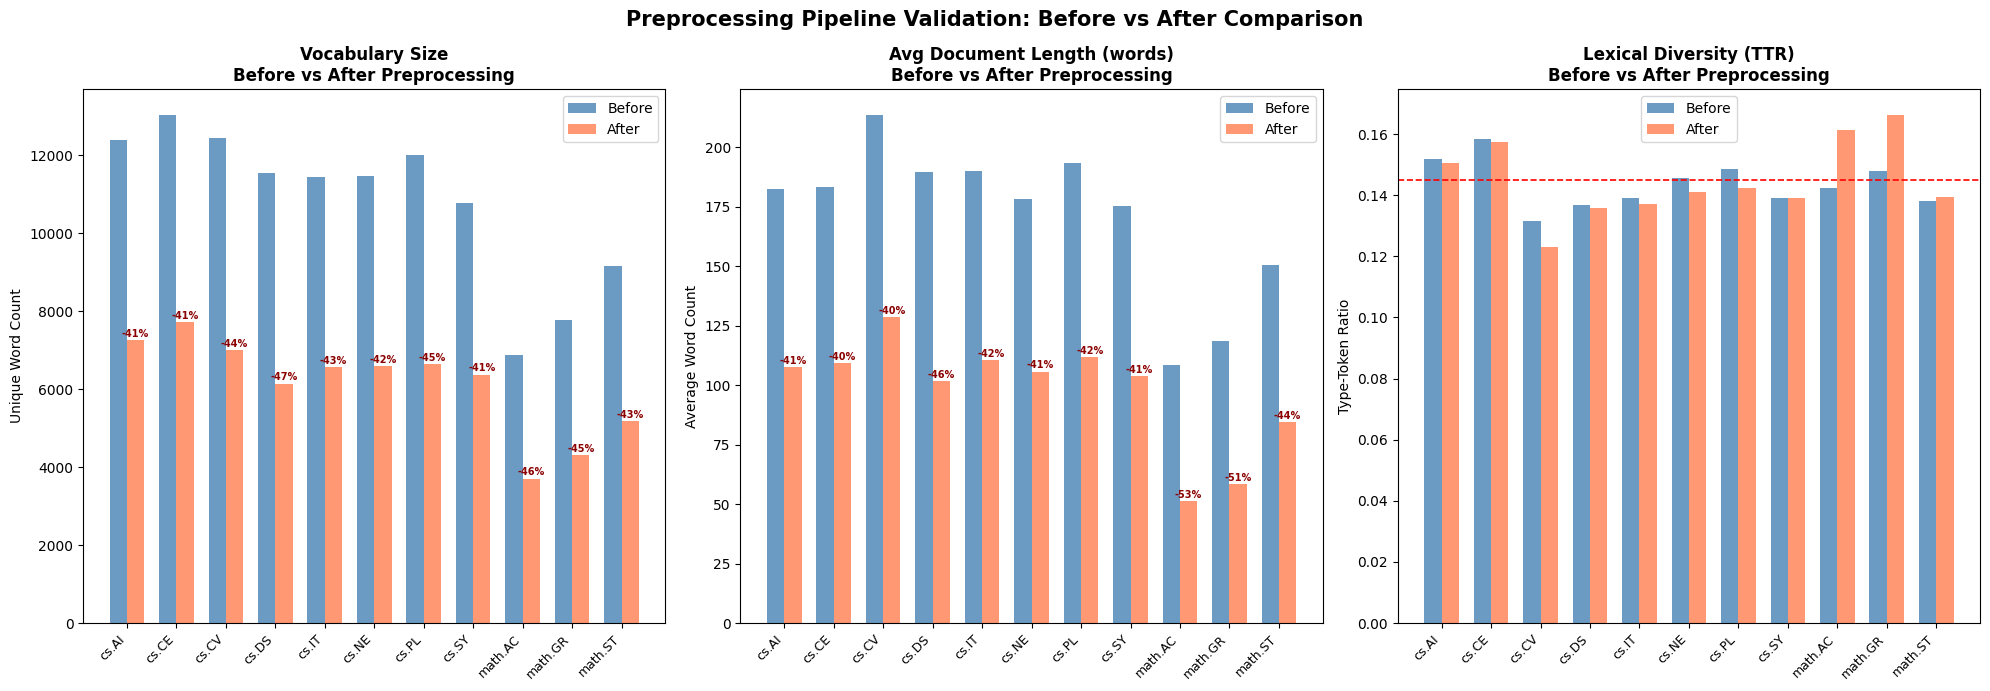


Preprocessing Validation Summary Table:
category  vocab_before  vocab_after  vocab_reduction_%  avg_len_before  avg_len_after  len_reduction_%  ttr_before  ttr_after
   cs.AI         12383         7250               41.5           182.4          107.7             40.9      0.1519     0.1506
   cs.CE         13038         7720               40.8           183.3          109.2             40.4      0.1584     0.1575
   cs.CV         12439         7000               43.7           213.8          128.6             39.9      0.1316     0.1232
   cs.DS         11535         6140               46.8           189.8          101.8             46.4      0.1369     0.1358
   cs.IT         11444         6555               42.7           190.2          110.4             41.9      0.1389     0.1371
   cs.NE         11459         6596               42.4           178.1          105.8             40.6      0.1455     0.1411
   cs.PL         12000         6639               44.7           193.5       

In [28]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# ==========================================
# FULL PREPROCESSING PIPELINE
# ==========================================

CUSTOM_PHRASE_STOP = [
    'et al', 'paper presents', 'paper propose', 'propose novel',
    'proposed method', 'experimental results', 'simulation results',
    'large scale', 'real world', 'state art', 'end end',
    'key words', 'subject classifications', 'subject descriptors',
    'paper proposes', 'et al.', 'pp qfix'
]

def preprocess(text):
    text = str(text).lower()
    # Remove filler phrases first
    for phrase in CUSTOM_PHRASE_STOP:
        text = text.replace(phrase, '')
    # Remove LaTeX artifacts
    text = re.sub(r'\$.*?\$', '', text)
    text = re.sub(r'\\[a-z]+\{.*?\}', '', text)
    text = re.sub(r'\\[a-z]+', '', text)
    # Remove citations
    text = re.sub(r'\[\d+\]', '', text)
    text = re.sub(r'\(\d{4}\)', '', text)
    # Remove special characters
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords + lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

print("⚙️ Running preprocessing pipeline...")
final_df['clean_abstract'] = final_df['abstract'].apply(preprocess)
print("✅ Done.")

# ==========================================
# COMPUTE BEFORE vs AFTER STATS
# ==========================================

def vocab_size(texts):
    words = []
    for t in texts:
        words.extend(str(t).lower().split())
    return len(set(words))

def avg_words(texts):
    return sum(len(str(t).split()) for t in texts) / len(texts)

def unique_ratio(texts):
    all_words = []
    for t in texts:
        all_words.extend(str(t).lower().split())
    return len(set(all_words)) / len(all_words)

categories_sorted = sorted(final_df['category'].unique())

before_vocab, after_vocab = [], []
before_avg, after_avg = [], []
before_ttr, after_ttr = [], []

for cat in categories_sorted:
    subset = final_df[final_df['category'] == cat]
    raw = subset['abstract'].tolist()
    clean = subset['clean_abstract'].tolist()

    before_vocab.append(vocab_size(raw))
    after_vocab.append(vocab_size(clean))
    before_avg.append(avg_words(raw))
    after_avg.append(avg_words(clean))
    before_ttr.append(unique_ratio(raw))
    after_ttr.append(unique_ratio(clean))

# ==========================================
# PLOT 10: 3 SIDE-BY-SIDE COMPARISONS
# ==========================================

x = np.arange(len(categories_sorted))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- subplot 1: Vocabulary size before vs after ---
axes[0].bar(x - width/2, before_vocab, width, label='Before', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, after_vocab, width, label='After', color='coral', alpha=0.8)
axes[0].set_title('Vocabulary Size\nBefore vs After Preprocessing', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories_sorted, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Unique Word Count')
axes[0].legend()

# Add % reduction labels on top of after bars
for i, (b, a) in enumerate(zip(before_vocab, after_vocab)):
    reduction = ((b - a) / b) * 100
    axes[0].text(i + width/2, a + 30, f'-{reduction:.0f}%',
                ha='center', va='bottom', fontsize=7, color='darkred', fontweight='bold')

# --- subplot 2: Average document length before vs after ---
axes[1].bar(x - width/2, before_avg, width, label='Before', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, after_avg, width, label='After', color='coral', alpha=0.8)
axes[1].set_title('Avg Document Length (words)\nBefore vs After Preprocessing', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories_sorted, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Average Word Count')
axes[1].legend()

for i, (b, a) in enumerate(zip(before_avg, after_avg)):
    reduction = ((b - a) / b) * 100
    axes[1].text(i + width/2, a + 0.5, f'-{reduction:.0f}%',
                ha='center', va='bottom', fontsize=7, color='darkred', fontweight='bold')

# --- subplot 3: TTR before vs after ---
axes[2].bar(x - width/2, before_ttr, width, label='Before', color='steelblue', alpha=0.8)
axes[2].bar(x + width/2, after_ttr, width, label='After', color='coral', alpha=0.8)
axes[2].set_title('Lexical Diversity (TTR)\nBefore vs After Preprocessing', fontsize=12, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(categories_sorted, rotation=45, ha='right', fontsize=9)
axes[2].set_ylabel('Type-Token Ratio')
axes[2].legend()
axes[2].axhline(y=np.mean(after_ttr), color='red', linestyle='--',
                linewidth=1.2, label='Post mean')

plt.suptitle('Preprocessing Pipeline Validation: Before vs After Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('eda10_preprocessing_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# PRINT SUMMARY TABLE
# ==========================================

summary = pd.DataFrame({
    'category': categories_sorted,
    'vocab_before': before_vocab,
    'vocab_after': after_vocab,
    'vocab_reduction_%': [round((b-a)/b*100, 1) for b,a in zip(before_vocab, after_vocab)],
    'avg_len_before': [round(x, 1) for x in before_avg],
    'avg_len_after': [round(x, 1) for x in after_avg],
    'len_reduction_%': [round((b-a)/b*100, 1) for b,a in zip(before_avg, after_avg)],
    'ttr_before': [round(x, 4) for x in before_ttr],
    'ttr_after': [round(x, 4) for x in after_ttr]
})

print("\nPreprocessing Validation Summary Table:")
print(summary.to_string(index=False))

# ==========================================
# SAVE FINAL PREPROCESSED CSV
# ==========================================

final_df.to_csv("radar_final_preprocessed.csv", index=False)
print("\n✅ Preprocessed dataset saved as radar_final_preprocessed.csv")
print(f"Final shape: {final_df.shape}")
print("\nSample clean abstract:")
print(final_df['clean_abstract'].iloc[0][:300])

In [36]:
# Check for empty strings after preprocessing (especially cs.NE had a zero-score doc)
empty = final_df[final_df['clean_abstract'].str.strip() == '']
print(f"Empty abstracts after preprocessing: {len(empty)}")

# Also confirm clean_abstract has no nulls
print(f"Null values: {final_df['clean_abstract'].isnull().sum()}")

# Quick sanity check on length
final_df['clean_word_count'] = final_df['clean_abstract'].apply(lambda x: len(str(x).split()))
print(f"\nClean abstract length stats:")
print(final_df['clean_word_count'].describe())

Empty abstracts after preprocessing: 0
Null values: 0

Clean abstract length stats:
count    4844.000000
mean       97.505367
std        62.112300
min         2.000000
25%        58.000000
50%        85.000000
75%       119.000000
max       694.000000
Name: clean_word_count, dtype: float64


In [41]:
final_df[final_df.duplicated(keep=False)]

,abstract,category,label,word_count,abstract_filtered,clean_abstract,clean_word_count


In [31]:
from google.colab import files

# Select only what you need for modeling — no intermediate columns
model_df = final_df[['clean_abstract', 'category']].copy()
model_df = model_df.reset_index(drop=True)

print(f"Shape: {model_df.shape}")
print(f"Columns: {model_df.columns.tolist()}")
print(f"\nCategory distribution:")
print(model_df['category'].value_counts())
print(f"\nSample:")
print(model_df.head(3))

# Save and download
model_df.to_csv("radar_modeling_ready_2cols.csv", index=False)
files.download("radar_modeling_ready_2cols.csv")
print("\n✅ Downloaded. Upload this to your new notebook.")

Shape: (4844, 2)
Columns: ['clean_abstract', 'category']

Category distribution:
category
cs.CE      449
cs.AI      447
math.AC    446
cs.DS      444
math.GR    443
cs.CV      442
cs.NE      442
cs.SY      441
math.ST    440
cs.IT      433
cs.PL      417
Name: count, dtype: int64

Sample:
                                      clean_abstract category
0  autonomous system substantially enhance human ...    cs.AI
1  paper develop novel paradigm namely hypergraph...    cs.AI
2  introduce framework leverage knowledge acquire...    cs.AI


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloaded. Upload this to your new notebook.
